In [6]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import json

from functions.functions_all import (
    get_tbm_target,
    get_target,
    build_ensemble_model_vote,
    walk_forward_validation_with_purging,
    run_stage4_for_ticker,
    get_all_features,
    json_converter
)

# Example use (0/1 classification)

In [ ]:
tickers = ["AAPL", "MSFT", "GOOGL"]

with open("../selected_features/feature_dict_binary.json", "r") as f:
    feature_dict = json.load(f)

output = {}
for share in tickers:
    data = pd.read_csv(f"../data/all_data/all_{share}_data.csv")
    df_tmp = get_target(data, share)
    features_aapl = get_all_features(df_tmp)
    print(f"------{share}-----")
        
    selected_features = feature_dict[share]
    print(f"Selected features for {share}:")
    print(f"Running for {share} with selected features ({len(selected_features)})")
    df, acc_smples, result = run_stage4_for_ticker(data, share, selected_features, model_version=build_ensemble_model_vote, target_type="binary", save_detailed_results=True)
    output[share] = result

with open("results/best_result(binary).json", "w") as f:
        json.dump(output, f, indent=2, default=json_converter)

------AAPL-----
Selected features for AAPL:
Running for AAPL with selected features (16)


# Example use (3 flags)

------AAPL-----
Selected features for AAPL:
Running for AAPL with selected features (21)
 WALK-FORWARD RESULTS for AAPL

--- Summary ---
      accuracy  precision    recall   roc_auc
Mean  0.419877   0.419433  0.419877  0.550618

--- Detailed Classification Report (Whole Period) ---
              precision    recall  f1-score   support

        -1.0       0.44      0.43      0.44       598
         0.0       0.28      0.27      0.28       321
         1.0       0.46      0.48      0.47       693

    accuracy                           0.42      1612
   macro avg       0.40      0.39      0.39      1612
weighted avg       0.42      0.42      0.42      1612


 BLOCK BOOTSTRAP for AAPL
95% CI accuracy: [0.3809, 0.4566]
Bootstrap mean accuracy: 0.4178


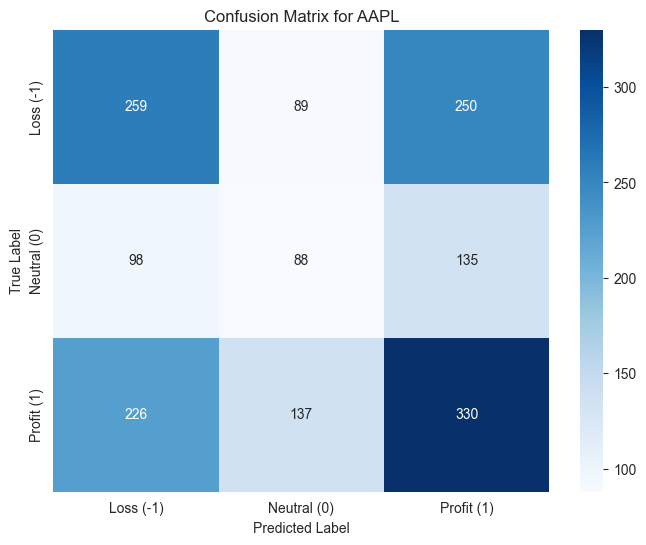

------MSFT-----
Selected features for MSFT:
Running for MSFT with selected features (17)
 WALK-FORWARD RESULTS for MSFT

--- Summary ---
      accuracy  precision    recall   roc_auc
Mean  0.419245   0.402411  0.419245  0.588689

--- Detailed Classification Report (Whole Period) ---
              precision    recall  f1-score   support

        -1.0       0.38      0.49      0.43       587
         0.0       0.36      0.24      0.29       356
         1.0       0.49      0.45      0.47       669

    accuracy                           0.42      1612
   macro avg       0.41      0.39      0.40      1612
weighted avg       0.42      0.42      0.41      1612


 BLOCK BOOTSTRAP for MSFT
95% CI accuracy: [0.3803, 0.4535]
Bootstrap mean accuracy: 0.4177


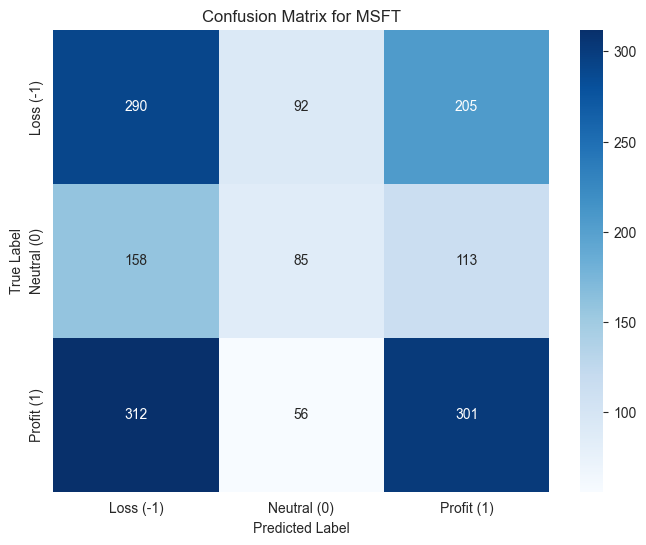

------GOOGL-----
Selected features for GOOGL:
Running for GOOGL with selected features (21)
 WALK-FORWARD RESULTS for GOOGL

--- Summary ---
      accuracy  precision    recall   roc_auc
Mean  0.416244   0.463015  0.416244  0.593049

--- Detailed Classification Report (Whole Period) ---
              precision    recall  f1-score   support

        -1.0       0.41      0.57      0.48       617
         0.0       0.39      0.29      0.33       377
         1.0       0.44      0.34      0.38       618

    accuracy                           0.42      1612
   macro avg       0.41      0.40      0.40      1612
weighted avg       0.42      0.42      0.41      1612


 BLOCK BOOTSTRAP for GOOGL
95% CI accuracy: [0.3859, 0.4535]
Bootstrap mean accuracy: 0.4182


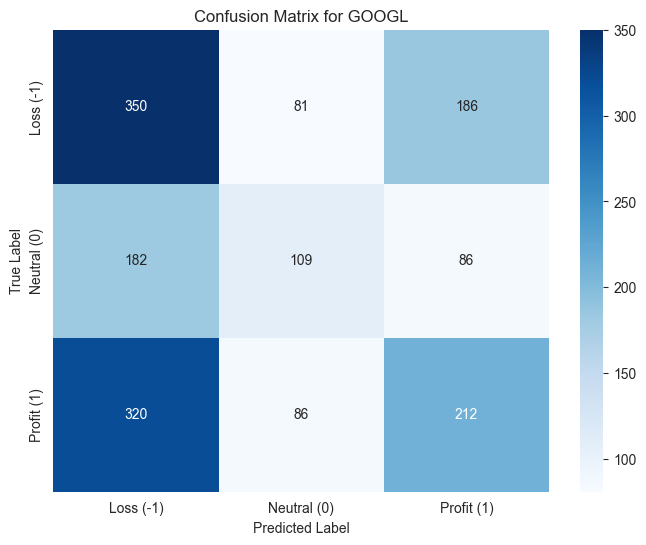

In [3]:
output = {}
with open("../selected_features/feature_dict_tbm.json", "r") as f:
    feature_dict = json.load(f)

for share in tickers:
    data = pd.read_csv(f"../data/all_data/all_{share}_data.csv")
    df_tmp = get_tbm_target(data, share)
    features = get_all_features(df_tmp)
    print(f"------{share}-----")
        
    selected_features = feature_dict[share]
    print(f"Selected features for {share}:")
    print(f"Running for {share} with selected features ({len(selected_features)})")
    df, acc_smples, result = run_stage4_for_ticker(data, share, selected_features, model_version=build_ensemble_model_vote, target_type="tbm", save_detailed_results=True)
    output[share] = result
    

In [4]:
print(output)

with open("results/best_result.json", "w") as f:
        json.dump(output, f, indent=2, default=json_converter)


{'AAPL': {'AAPL': {'summary':       accuracy  precision    recall   roc_auc
Mean  0.419877   0.419433  0.419877  0.550618, 'Bootstrap mean accuracy': np.float64(0.4178473945409429)}}, 'MSFT': {'MSFT': {'summary':       accuracy  precision    recall   roc_auc
Mean  0.419245   0.402411  0.419245  0.588689, 'Bootstrap mean accuracy': np.float64(0.41768672456575684)}}, 'GOOGL': {'GOOGL': {'summary':       accuracy  precision    recall   roc_auc
Mean  0.416244   0.463015  0.416244  0.593049, 'Bootstrap mean accuracy': np.float64(0.4181954094292804)}}}


## Comparison

In [7]:
ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

from Baseline_model.baselines import get_lr_model, get_rf_model, get_xgboost_model, get_dummy_model, get_svm_model

aapl_with_features = pd.read_csv('../data/all_data/all_AAPL_data.csv')
googl_with_features = pd.read_csv('../data/all_data/all_GOOGL_data.csv')
msft_with_features = pd.read_csv('../data/all_data/all_MSFT_data.csv')

tickers = ['AAPL', 'GOOGL', 'MSFT']
data_dict = {
    'AAPL': aapl_with_features,
    'GOOGL': googl_with_features,
    'MSFT': msft_with_features
}
color_dict = {
     'AAPL': 'grey',
    'GOOGL': 'yellow',
    'MSFT': 'green'
}

models_to_test = {
    'XGBoost': get_xgboost_model,
    'SVM': get_svm_model,
    'RandomForest': get_rf_model,
    'LogReg': get_lr_model,
    'Baseline_AlwaysBuy': get_dummy_model
}

all_results_comparison = {}


for ticker in tickers:
    all_results_comparison[ticker] = {}
    df_raw = data_dict[ticker]

    df_target = get_tbm_target(df_raw, ticker, pt_sl=[1.3, 1.0])
    
    df_target['Target'] = df_target['Target'].map({-1.0: 0, 0.0: 1, 1.0: 2})
    
    selected_features = feature_dict.get(ticker, [])
    
    if not selected_features:
        features_to_exclude = ['Target', 'DATE', 'index'] + [c for c in df_target.columns if 'Target' in c]
        selected_features = [c for c in df_target.columns if c not in features_to_exclude and np.issubdtype(df_target[c].dtype, np.number)]

    for model_name, model_func in models_to_test.items():
        
        folds_df, y_true, y_pred, y_proba = walk_forward_validation_with_purging(
                df=df_target,
                features=selected_features,
                model_version=model_func,
                type='tbm',
                target_col="Target",
                date_col="DATE",
                start_year=2010,       
                first_train_end_year=2015,
                last_test_year=2023,
            
        )
            
        if not folds_df.empty:
            mean_metrics = folds_df[['accuracy', 'precision', 'recall', 'roc_auc']].mean()
            print(f"    Result {model_name}: Acc={mean_metrics['accuracy']:.3f}, Prec={mean_metrics['precision']:.3f}, Recall={mean_metrics['recall']:.3f}, AUC={mean_metrics['roc_auc']:.3f}")
                
            all_results_comparison[ticker][model_name] = mean_metrics
            

summary_data = []

for ticker, models_res in all_results_comparison.items():
    if models_res: 
        row = {'Ticker': ticker}
        for model_name, metrics in models_res.items():
            row[model_name] = metrics['precision']
        summary_data.append(row)

if summary_data:
    df_summary = pd.DataFrame(summary_data)
    display(df_summary) if 'display' in locals() else print(df_summary)


KeyError: "['RSI_14_MSFT', 'MACDh_12_26_9_MSFT', 'BBB_20_2.0_2.0_MSFT', 'BBP_20_2.0_2.0_MSFT', 'RSI_14_GOOGL', 'ATRr_14_GOOGL', 'BBB_20_2.0_2.0_GOOGL', 'dist_to_max_20', 'dist_to_min_20', 'dist_to_max_60', 'dist_to_min_60', 'FinBERT_MA7'] not in index"

In [ ]:
with open('results/best_result.json', 'r') as f:
        main_model_data = json.load(f)

final_data = []

for ticker, models in all_results_comparison.items():
    for model_name, metrics in models.items():
        final_data.append({
            'Ticker': ticker,
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'ROC_AUC': metrics['roc_auc']
        })

for ticker in tickers:
    if ticker in main_model_data:
        data_node = main_model_data[ticker]
        if ticker in data_node: 
            data_node = data_node[ticker]
            
        summary = data_node.get('summary', {})
            
        final_data.append({
            'Ticker': ticker,
            'Model': 'Main Model (TBM)',
            'Accuracy': summary['accuracy']['Mean'],
            'Precision': summary['precision']['Mean'],
            'Recall': summary['recall']['Mean'],
            'ROC_AUC': summary['roc_auc']['Mean']
            })
        
        
df_final_comparison = pd.DataFrame(final_data)
df_pivot = df_final_comparison.pivot(index='Ticker', columns='Model', values='Precision')
display(df_pivot.style.background_gradient(cmap='Greens', axis=1).format("{:.2%}")) if 'display' in locals() else print(df_pivot)

df_detailed = df_final_comparison.sort_values(by=['Ticker', 'Precision'], ascending=[True, False])
display(df_detailed) if 'display' in locals() else print(df_detailed)
    
df_final_comparison.to_csv('results/final_comparison_all_models.csv', index=False)

Model   Baseline_AlwaysBuy    LogReg  Main Model (TBM)  RandomForest  \
Ticker                                                                 
AAPL              0.040825  0.403875          0.384804      0.387466   
GOOGL             0.056054  0.418441          0.424929      0.420471   
MSFT              0.052648  0.401309          0.436017      0.450148   

Model        SVM   XGBoost  
Ticker                      
AAPL    0.385300  0.355655  
GOOGL   0.354590  0.423246  
MSFT    0.433008  0.369190  
   Ticker               Model  Accuracy  Precision    Recall   ROC_AUC
3    AAPL              LogReg  0.370477   0.403875  0.370477  0.556188
2    AAPL        RandomForest  0.419693   0.387466  0.419693  0.517861
1    AAPL                 SVM  0.383421   0.385300  0.383421  0.527082
15   AAPL    Main Model (TBM)  0.393773   0.384804  0.393773  0.535423
0    AAPL             XGBoost  0.382757   0.355655  0.382757  0.514083
4    AAPL  Baseline_AlwaysBuy  0.198044   0.040825  0.198044  0.5000